<center><p><font size="6" color='blue' class="alert alert-success"><b>ANALYSE DES DONNNES de l'entreprise AfriMarket</b></font></p><center>

<div style="background-color: #0f172a; border: 1px solid #067692; border-radius: 15px; padding: 25px; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-shadow: 0 10px 20px rgba(0,0,0,0.4); max-width: 750px; margin: auto;">
<center>
<p>
<font size="5" color='#38bdf8' style="letter-spacing: 1.5px; text-transform: uppercase;">
<b>1)Audit & Compréhension des Données</b>
</font>
</p>
</center>

<div style="margin-top: 15px; border-top: 1px solid rgba(56, 189, 248, 0.2); padding-top: 15px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 500; margin-bottom: 12px;">
<b>Analyse de Structure et Qualité :</b>
</p>
<p style="color: #cbd5e1; font-size: 1em; line-height: 1.6em;">
Le fichier <span style="color: #38bdf8; font-family: 'Courier New', monospace;">afrimarket_dataset_senior.csv</span> contient l'historique des transactions. L'audit révèle des problèmes critiques d'intégrité : incohérences typographiques (ex: <span style="color: #fbbf24;">"Kinshasa"</span> vs <span style="color: #fbbf24;">"Kinshassa"</span>), valeurs aberrantes de prix négatifs (-50.0) et quantités nulles, nécessitant un nettoyage rigoureux pour garantir la fiabilité des KPIs.
</p>
</div>

<div style="background-color: #1e293b; border-radius: 8px; padding: 8px; margin-top: 20px; font-family: 'Courier New', monospace; color: #e2e8f0; font-size: 0.85em; line-height: 1.4em; border: 1px solid rgba(56, 189, 248, 0.1);">
<span style="color: #94a3b8;"># État des lieux technique</span>


Structure : 14 colonnes (IDs, Temporel, Géographique, Financier, Marketing)


Doublons : À vérifier sur id_commande

Valeurs aberrantes : <span style="color: #fbbf24;">prix_unitaire < 0</span>, <span style="color: #fbbf24;">quantite = 0</span>, <span style="color: #fbbf24;">remise < 0</span> 
</div>

<div style="margin-top: 25px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 400; margin-bottom: 12px;">
<center><b>Dictionnaire des Variables & Anomalies :</b></center>
</p>
<div style="overflow-x:auto;">
<table style="width: 100%; color: #cbd5e1; font-size: 0.82em; border-collapse: collapse; line-height: 1.3em;">
<thead>
<tr style="border-bottom: 2px solid rgba(56, 189, 248, 0.2); text-align: left;">
<th style="padding: 10px">Variable</th>
<th style="padding: 10px">Type</th>
<th style="padding: 10px">Problèmes Détectés</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">date_commande</td>
<td style="padding: 8px;">Object</td>
<td style="padding: 8px;">À convertir en Datetime pour l'analyse temporelle.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">ville</td>
<td style="padding: 8px;">String</td>
<td style="padding: 8px;">Doublons d'orthographe (Kinshasa/Kinshassa).</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">categorie</td>
<td style="padding: 8px;">String</td>
<td style="padding: 8px;">Casse incohérente (electronique vs Électronique).</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">prix_unitaire</td>
<td style="padding: 8px;">Float</td>
<td style="padding: 8px;">Présence de valeurs négatives (-50.0).</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">quantite</td>
<td style="padding: 8px;">Int</td>
<td style="padding: 8px;">Transactions à 0 unité détectées.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">remise</td>
<td style="padding: 8px;">Float</td>
<td style="padding: 8px;">Remises négatives (-0.1) identifiées.</td>
</tr>
<tr>
<td style="padding: 8px; font-family: monospace;">statut_commande</td>
<td style="padding: 8px;">String</td>
<td style="padding: 8px;">Indicateur clé pour filtrer le CA réel (Livrée vs Annulée).</td>
</tr>
</tbody>
</table>
</div>
</div>
</div>

<center><p><font size="5" color='cyan' class="alert alert-primary"><b>Importation des bibliothèques nécessaires pour le projet</b></font></p><center>

In [657]:
#importation des bibliothèques nécessaires pour le projet
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


<center><p><font size="5" color='cyan' class="alert alert-primary"><b>Chargement des données à partir du fichier afrimarket_dataset.csv</b></font></p><center>

In [658]:
#Chargement des données à partir du fichier CSV
afrimarket = pd.read_csv('afrimarket_dataset.csv')

<center><p><font size="5" color='cyan' class="alert alert-primary"><b>Verification des etats des colonnes</b></font></p><center>

In [659]:
afrimarket['ville'].unique()

array(['Brazzaville', 'Libreville', 'Abidjan', 'Dakar', 'Lomé', 'Cotonou',
       'Kinshasa', 'Douala', 'Kinshassa'], dtype=object)

In [660]:
afrimarket['ville'].value_counts()

ville
Kinshasa       2349
Abidjan        1886
Douala         1449
Dakar          1434
Lomé            735
Cotonou         677
Kinshassa       605
Libreville      493
Brazzaville     472
Name: count, dtype: int64

In [661]:
afrimarket['categorie'].unique()

array(['Mode', 'Beauté', 'electronique', 'Électronique', 'Maison'],
      dtype=object)

In [662]:
afrimarket['categorie'].value_counts()

categorie
Mode            3005
Électronique    2638
Maison          1948
Beauté          1903
electronique     606
Name: count, dtype: int64

In [663]:
afrimarket['quantite'].unique()

array([3, 2, 0, 1])

In [664]:
afrimarket['quantite'].value_counts()

quantite
1    3226
2    3177
3    3089
0     608
Name: count, dtype: int64

In [665]:
afrimarket['quantite'].describe()

count    10100.000000
mean         1.866040
std          0.920966
min          0.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          3.000000
Name: quantite, dtype: float64

In [666]:
afrimarket['remise'].unique()

array([ 0.07,  0.1 ,  0.04,  0.03,  0.02, -0.1 ,  0.14,  0.15,  0.08,
        0.09,  0.23,  0.25,  0.22,  0.27,  0.29,  0.05,  0.17,  0.16,
        0.11,  0.24,  0.13,  0.06,  0.01,  0.18,  0.28,  0.26,  0.  ,
        0.3 ,  0.2 ,  0.21,  0.19,  0.12])

In [667]:
afrimarket['statut_commande'].unique()

array(['Livrée', 'retournée', 'Annulée'], dtype=object)

<div style="background-color: #0f172a; border: 1px solid #067692; border-radius: 10px; padding: 10px; font-family: 'Segoe UI', sans-serif; box-shadow: 0 5px 20px rgba(0,0,0,0.5); max-width: 600px; margin: auto;">

<div style="text-align: center; margin-bottom: 12px; border-bottom: 1px solid rgba(56, 189, 248, 0.2); padding-bottom: 8px;">
<h3 style="color: #38bdf8; letter-spacing: 2px; text-transform: uppercase; margin: 0; font-size: 1.1em; font-weight: 700;">
🎯 # PHASE 1: Audit & Compréhension des données
</h3>
</div>

<div style="display: flex; flex-wrap: wrap; gap: 8px; justify-content: center;">

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">📊</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Analyse de structure</span>
</div>

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">🧬</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Types de données</span>
</div>

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">❓</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Valeurs manquantes</span>
</div>

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">👯</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Doublons</span>
</div>

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">📉</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Valeurs aberrantes</span>
</div>

<div style="flex: 1 1 45%; background: rgba(30, 41, 59, 0.7); border: 1px solid rgba(56, 189, 248, 0.3); border-radius: 6px; padding: 6px 12px; display: flex; align-items: center; min-width: 200px;">
  <span style="color: #38bdf8; margin-right: 10px; font-size: 1.2em;">✨</span>
  <span style="color: #f1f5f9; font-size: 0.9em; font-weight: 500;">Problèmes de qualité</span>
</div>

</div>
</div>

In [668]:
#1-Analyse et structure des données
print("les 5 premières lignes du dataset :")
afrimarket.head()

les 5 premières lignes du dataset :


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
2,CMD100002,2025-07-08,C0119,Abidjan,electronique,Produit_Électronique_36,315.60,0,0.04,5.60,Carte,Google Ads,7.30,Livrée
3,CMD100003,2025-08-20,C1436,Libreville,electronique,Produit_Électronique_29,143.25,0,0.03,5.96,Mobile Money,Google Ads,5.20,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée


In [669]:
# --- 1. ANALYSE DE STRUCTURE ---
print(f"\nSTRUCTURE DES DONNEES : {afrimarket.shape[0]} lignes et {afrimarket.shape[1]} colonnes.")



# --- 2. TYPES DE DONNÉES ---
print("\n\n\nTYPES DES DONNEES : Vérification des formats colonnes\n")
print(afrimarket.dtypes)



# --- 3. VALEURS MANQUANTES ---
print("\n\n\nVALEURS MANQUANTES :")
val_mqte = afrimarket.isnull().sum()
print(val_mqte[val_mqte > 0] if val_mqte.any() else "Aucune donnée manquante.")


STRUCTURE DES DONNEES : 10100 lignes et 14 colonnes.



TYPES DES DONNEES : Vérification des formats colonnes

id_commande          object
date_commande        object
id_client            object
ville                object
categorie            object
nom_produit          object
prix_unitaire       float64
quantite              int64
remise              float64
cout_livraison      float64
methode_paiement     object
canal_marketing      object
cout_marketing      float64
statut_commande      object
dtype: object



VALEURS MANQUANTES :
Aucune donnée manquante.


In [670]:
#4 VERIFICATION DES VALEURS DOUBLONS
print("\nVALEURS DOUBLONS :")
afrimarket[afrimarket.duplicated()]


VALEURS DOUBLONS :


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
10000,CMD102576,2025-07-31,C0924,Kinshasa,Mode,Produit_Mode_14,13.63,1,0.24,7.42,Paiement à la livraison,Google Ads,7.62,retournée
10001,CMD102940,2025-09-24,C0039,Brazzaville,Mode,Produit_Mode_45,44.07,1,0.10,9.77,Carte,Google Ads,7.80,Livrée
10002,CMD107540,2025-09-21,C1880,Abidjan,Électronique,Produit_Électronique_14,-50.00,1,0.04,7.34,Mobile Money,Google Ads,4.76,Livrée
10003,CMD104223,2025-12-12,C1305,Cotonou,Mode,Produit_Mode_28,32.56,2,0.26,8.42,Paiement à la livraison,Instagram Ads,8.40,Livrée
10004,CMD100232,2025-10-10,C0086,Dakar,Mode,Produit_Mode_5,45.86,0,0.25,4.36,Paiement à la livraison,Email,0.58,Livrée
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10095,CMD104520,2025-10-07,C0176,Brazzaville,Beauté,Produit_Beauté_44,24.82,1,0.10,3.75,Carte,Instagram Ads,8.06,Livrée
10096,CMD108770,2025-12-27,C0009,Kinshasa,Mode,Produit_Mode_37,21.12,0,0.12,8.91,Virement,Instagram Ads,10.46,Livrée
10097,CMD107567,2025-11-22,C0099,Kinshasa,electronique,Produit_Maison_42,90.60,0,-0.10,5.53,Paiement à la livraison,Google Ads,4.55,Livrée
10098,CMD109850,2025-09-22,C0292,Abidjan,Beauté,Produit_Beauté_48,29.13,1,0.20,9.47,Paiement à la livraison,Instagram Ads,9.88,Livrée


In [671]:
# --- 5. VALEURS ABERRANTES ---
print("\n=== AUDIT DES ANOMALIES FINANCIÈRES ===\n")

# Calcul des anomalies
prix_neg = (afrimarket['prix_unitaire'] < 0).sum()
quantite_anormale = (afrimarket['quantite'] <= 0).sum()
remise_invalide = ((afrimarket['remise'] < 0) | (afrimarket['remise'] > 1)).sum()

total_lignes = len(afrimarket)

# Affichage formaté avec pourcentage
print(f" Prix unitaires négatifs        : {prix_neg} ({prix_neg/total_lignes:.2%})\n")
print(f" Quantités nulles ou négatives  : {quantite_anormale} ({quantite_anormale/total_lignes:.2%})\n")
print(f" Remises hors plage [0, 1]      : {remise_invalide} ({remise_invalide/total_lignes:.2%})\n")


=== AUDIT DES ANOMALIES FINANCIÈRES ===

 Prix unitaires négatifs        : 632 (6.26%)

 Quantités nulles ou négatives  : 608 (6.02%)

 Remises hors plage [0, 1]      : 614 (6.08%)



<div style="background-color: #0f172a; border: 1px solid #067692; border-radius: 15px; padding: 25px; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-shadow: 0 10px 20px rgba(0,0,0,0.4); max-width: 750px; margin: auto;">
<center>
<p>
<font size="5" color='#38bdf8' style="letter-spacing: 1.5px; text-transform: uppercase;">
<b>2)Nettoyage & Traitement des Données(Data cleaning)</b>
</font>
</p>
</center>

<div style="margin-top: 15px; border-top: 1px solid rgba(56, 189, 248, 0.2); padding-top: 15px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 500; margin-bottom: 12px;">
<b>Stratégie de Correction :</b>
</p>
<p style="color: #cbd5e1; font-size: 1em; line-height: 1.6em;">
Cette phase transforme le dataset brut en une base de données fiable. L'objectif est de supprimer le "bruit" statistique (erreurs de saisie et valeurs impossibles) pour que chaque ligne représente une transaction commerciale réelle et cohérente.
</p>
</div>

<div style="background-color: #1e293b; border-radius: 8px; padding: 5px; margin-top: 20px; font-family: 'Courier New', monospace; color: #e2e8f0; font-size: 0.85em; line-height: 1.4em; border: 1px solid rgba(56, 189, 248, 0.1);">
<span style="color: #94a3b8;"># Script de mise en conformité</span>


Dates : Conversion <span style="color: #fbbf24;">Object -> Datetime</span>


Doublons : Déduplication stricte sur <span style="color: #fbbf24;">id_commande</span>


Filtrage : Exclusion des <span style="color: #fbbf24;">quantités <= 0</span> et <span style="color: #fbbf24;">prix <= 0</span>
</div>

<div style="margin-top: 25px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 400; margin-bottom: 12px;">
<center><b>Plan d'action par Variable :</b></center>
</p>
<div style="overflow-x:auto;">
<table style="width: 100%; color: #cbd5e1; font-size: 0.82em; border-collapse: collapse; line-height: 1.3em;">
<thead>
<tr style="border-bottom: 2px solid rgba(56, 189, 248, 0.2); text-align: left;">
<th style="padding: 10px">Variable</th>
<th style="padding: 10px">Action de Nettoyage</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">ville</td>
<td style="padding: 8px;">Correction orthographique (Mapping) et suppression des espaces.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">categorie</td>
<td style="padding: 8px;">Uniformisation de la casse et gestion des accents.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">remise</td>
<td style="padding: 8px;">Correction des valeurs négatives en valeurs absolues.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">statut</td>
<td style="padding: 8px;">Standardisation des labels (Livrée, Retournée, Annulée).</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace;">outliers</td>
<td style="padding: 8px;">Suppression des transactions aberrantes (prix ou quantités nulles).</td>
</tr>
</tbody>
</table>
</div>
</div>
</div

<center><p><font size="5" color='cyan' class="alert alert-primary"><b># 2. PHASE DE NETTOYAGE (DATA CLEANING)</b></font></p><center>

In [672]:
# --- 1. GESTION DES DOUBLONS ---
# On élimine les doublons basés sur l'identifiant unique de commande
afrimarket = afrimarket.drop_duplicates(subset='id_commande')

# --- 2. STANDARDISATION DES DATES ---
# Conversion en format datetime pour permettre les analyses temporelles
afrimarket['date_commande'] = pd.to_datetime(afrimarket['date_commande'])

# --- 3. UNIFORMISATION DES CATÉGORIES ---
# Nettoyage de la casse, suppression des espaces et gestion de l'accentuation
afrimarket['categorie'] = afrimarket['categorie'].str.strip().str.lower()
# On corrige "electronique" en "électronique" AVANT de mettre la majuscule
afrimarket['categorie'] = afrimarket['categorie'].str.replace('electronique', 'électronique', regex=False)
afrimarket['categorie'] = afrimarket['categorie'].str.capitalize()

# --- 4. CORRECTION DES VILLES ---
# Nettoyage initial pour éviter les erreurs de correspondance
afrimarket['ville'] = afrimarket['ville'].str.strip().str.lower()
corrections_villes = {
    'kinshassa': 'kinshasa',
    'dakar_': 'dakar',
    'abidjan ': 'abidjan' # Sécurité supplémentaire au cas où
}
afrimarket['ville'] = afrimarket['ville'].replace(corrections_villes)
afrimarket['ville'] = afrimarket['ville'].str.capitalize()

# --- 5. TRAITEMENT DES VALEURS NUMÉRIQUES ABERRANTES ---
# Gestion des prix unitaires : on transforme les négatifs en positifs (correction d'erreur de signe)
afrimarket['prix_unitaire'] = afrimarket['prix_unitaire'].abs()

# Gestion des quantités : On filtre pour ne garder que les transactions réelles (> 0)
# Note : On utilise .copy() pour éviter les avertissements "SettingWithCopy" plus tard
afrimarket = afrimarket[afrimarket['quantite'] > 0].copy()
afrimarket['quantite'] = afrimarket['quantite'].astype(int)

# --- 6. GESTION DES REMISES ---
# Conversion des valeurs négatives et plafonnement à 100% (1.0)
afrimarket['remise'] = afrimarket['remise'].abs()
afrimarket['remise'] = afrimarket['remise'].clip(upper=1)

# --- 7. UNIFORMISATION DES STATUTS DE COMMANDE ---
afrimarket['statut_commande'] = afrimarket['statut_commande'].str.strip().str.capitalize()

# --- VÉRIFICATION FINALE APRÈS NETTOYAGE ---
print("=== VÉRIFICATION FINALE APRÈS NETTOYAGE ===\n")
print(f"Nombre de lignes finales : {afrimarket.shape[0]} ligne et {afrimarket.shape[1]} colonnes.\n")
print("\nTypes de données après nettoyage :\n")
print(f"{afrimarket.dtypes}\n")
# Affichage des premières lignes pour confirmation visuelle
print("\n=================Aperçu des données nettoyées :====================\n")
afrimarket.head()

=== VÉRIFICATION FINALE APRÈS NETTOYAGE ===

Nombre de lignes finales : 9400 ligne et 14 colonnes.


Types de données après nettoyage :

id_commande                 object
date_commande       datetime64[ns]
id_client                   object
ville                       object
categorie                   object
nom_produit                 object
prix_unitaire              float64
quantite                     int64
remise                     float64
cout_livraison             float64
methode_paiement            object
canal_marketing             object
cout_marketing             float64
statut_commande             object
dtype: object


=================Aperçu des données nettoyées :====================



,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,Livrée
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,Virement,Instagram Ads,9.23,Livrée


<div style="background-color: #0f172a; border: 1px solid #22c55e; border-radius: 10px; padding: 20px; font-family: 'Segoe UI', sans-serif; max-width: 750px; margin: auto; box-shadow: 0 4px 15px rgba(0,0,0,0.3);">
    <h3 style="color: #22c55e; margin-top: 0; font-size: 1.2em; text-align: center; text-transform: uppercase; letter-spacing: 1.5px;">
        ✅ Synthèse du Nettoyage de Données
    </h3>

<div style="display: flex; justify-content: space-around; align-items: center; margin: 20px 0; border-bottom: 1px solid rgba(255,255,255,0.1); padding-bottom: 20px;">
<div style="text-align: center;">
<p style="color: #94a3b8; font-size: 0.8em; margin: 0; text-transform: uppercase;">Volume Initial</p>
<p style="color: #f1f5f9; font-size: 1.6em; font-weight: bold; margin: 0;">10 100</p>
<p style="color: #64748b; font-size: 0.75em;">lignes brutes</p>
</div>
<div style="color: #38bdf8; font-size: 2em; font-weight: 200;">→</div>
<div style="text-align: center;">
<p style="color: #22c55e; font-size: 0.8em; margin: 0; text-transform: uppercase;">Volume Nettoyé</p>
<p style="color: #f1f5f9; font-size: 1.6em; font-weight: bold; margin: 0;">9 400</p>
<p style="color: #64748b; font-size: 0.75em;">données fiables</p>
</div>
<div style="color: #ef4444; font-size: 2em; font-weight: 200;">→</div>
<div style="text-align: center;">
<p style="color: #94a3b8; font-size: 0.8em; margin: 0; text-transform: uppercase;">Écart (Supprimé)</p>
<p style="color: #ef4444; font-size: 1.6em; font-weight: bold; margin: 0;">700</p>
<p style="color: #64748b; font-size: 0.75em;">anomalies</p>
</div>
</div>

<div style="color: #cbd5e1; font-size: 0.95em; line-height: 1.6em;">
<p style="margin-bottom: 10px;"><b>Détails des opérations :</b></p>
<ul style="list-style: none; padding-left: 0;">
<li style="margin-bottom: 8px;">
                <span style="color: #38bdf8; font-weight: bold;">• - 100 lignes :</span> Doublons techniques supprimés (ID commande identiques).
</li>
<li style="margin-bottom: 8px;">
                <span style="color: #fbbf24; font-weight: bold;">• - 600 lignes :</span> Erreurs métiers critiques (Quantités nulles ou négatives).
</li>
<li style="margin-bottom: 8px;">
                <span style="color: #10b981; font-weight: bold;">• Corrigés :</span> Prix négatifs redressés et remises plafonnées à 100%.
</li>
</ul>
</div>

<div style="margin-top: 20px; background: rgba(34, 197, 94, 0.1); padding: 12px; border-radius: 6px; text-align: center; border: 1px dashed #22c55e;">
        <span style="color: #22c55e; font-size: 0.9em; font-weight: 600;">🚀 Statut : Audit terminé. Dataset prêt pour l'analyse de performance.</span>
</div>
</div>

<center><p><font size="5" color='cyan' class="alert alert-primary"><b>CREATION DU DATASET PROPRE Afri_Net(df_clean)</b></font></p><center>

In [673]:
# On crée une copie profonde pour éviter les avertissements
Afri_Net = afrimarket.copy(deep=True)
print("\n=== DATASET PROPRE Afri_Net (df_clean) ===")
Afri_Net.head()


=== DATASET PROPRE Afri_Net (df_clean) ===


,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,methode_paiement,canal_marketing,cout_marketing,statut_commande
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,Mobile Money,Email,1.00,Livrée
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,Paiement à la livraison,Instagram Ads,8.04,Livrée
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,Mobile Money,Email,0.55,Livrée
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,Virement,Instagram Ads,5.45,Livrée
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,Virement,Instagram Ads,9.23,Livrée


<div style="background-color: #0f172a; border: 1px solid #38bdf8; border-radius: 15px; padding: 25px; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-shadow: 0 10px 20px rgba(0,0,0,0.4); max-width: 750px; margin: auto;">
<center>
<p>
<font size="5" color='#38bdf8' style="letter-spacing: 1.5px; text-transform: uppercase;">
<b>3) Enrichissement des Données (Feature Engineering)</b>
</font>
</p>
</center>

<div style="margin-top: 15px; border-top: 1px solid rgba(56, 189, 248, 0.2); padding-top: 15px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 500; margin-bottom: 12px;">
<b>Objectif Stratégique :</b>
</p>
<p style="color: #cbd5e1; font-size: 1em; line-height: 1.6em;">
Transformation des variables brutes en <b>indicateurs de performance (KPIs)</b>. Cette étape permet de passer d'une simple liste de transactions à une analyse de rentabilité profonde (Profit, Marge et Valeur Client).
</p>
</div>

<div style="background-color: #1e293b; border-radius: 8px; padding: 5px; margin-top: 20px; font-family: 'Courier New', monospace; color: #e2e8f0; font-size: 0.85em; line-height: 1.4em; border: 1px solid rgba(56, 189, 248, 0.1);">
<span style="color: #94a3b8;"># Formules de calcul financier</span>

CA Net = <span style="color: #fbbf24;">(Prix * Qté) * (1 - Remise)</span>


Profit Net = <span style="color: #fbbf24;">Marge - (Logistique + Marketing)</span>


CLV = <span style="color: #fbbf24;">Σ Profit_Net par Client</span>

</div>

<div style="margin-top: 25px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 400; margin-bottom: 12px;">
<center><b>Nouveaux Indicateurs Créés :</b></center>
</p>
<div style="overflow-x:auto;">
<table style="width: 100%; color: #cbd5e1; font-size: 0.82em; border-collapse: collapse; line-height: 1.3em;">
<thead>
<tr style="border-bottom: 2px solid rgba(56, 189, 248, 0.2); text-align: left;">
<th style="padding: 10px">Variable</th>
<th style="padding: 10px">Description Métier</th>
<th style="padding: 10px">Utilité Analyse</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace; color: #38bdf8;">chiffre_affaires</td>
<td style="padding: 8px;">Revenu réel après remises.</td>
<td style="padding: 8px;">Volume d'affaires global.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace; color: #38bdf8;">profit_net</td>
<td style="padding: 8px;">Résultat final (CA - Coûts).</td>
<td style="padding: 8px;">Mesure de rentabilité réelle.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace; color: #38bdf8;">mois</td>
<td style="padding: 8px;">Mois de la transaction.</td>
<td style="padding: 8px;">Analyse de saisonnalité.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace; color: #38bdf8;">indicateur_retour</td>
<td style="padding: 8px;">Flag binaire (Retour/Annulation).</td>
<td style="padding: 8px;">Suivi du taux de défaillance.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-family: monospace; color: #38bdf8;">valeur_vie_client</td>
<td style="padding: 8px;">CLV (Customer Lifetime Value).</td>
<td style="padding: 8px;">Identification des clients VIP.</td>
</tr>
</tbody>
</table>
</div>
</div>
</div>

<center><p><font size="5" color='cyan' class="alert alert-primary"><b># 3. PHASE DE FEATURE ENGINEERING</b></font></p><center>

In [674]:
#1. Chiffre d'affaires net (CA Net) : Calcul du CA net en tenant compte des remises
Afri_Net['CA_Net'] = (Afri_Net['prix_unitaire'] * Afri_Net['quantite']) * (1 - Afri_Net['remise'])


#2. Marge brute : Calcul de la marge brute en soustrayant le coût des marchandises vendues du CA net

# Supposons un coût de 60% du prix unitaire pour le calcul de la marge brute
Afri_Net['Marge_Brute'] = Afri_Net['CA_Net'] - (Afri_Net['quantite'] * Afri_Net['prix_unitaire'] * 0.6)  


#3. Profit net estimé : Calcul du profit net en soustrayant les coûts de marketing et de livraison de la marge brute
Afri_Net['profit_net'] = Afri_Net['Marge_Brute'] - (Afri_Net['cout_marketing'] + Afri_Net['cout_livraison'])


#4. Extraction du Mois (Pour l'analyse temporelle)
Afri_Net['mois'] = Afri_Net['date_commande'].dt.month_name()


#5. Indicateur de Retour (1 si annulé ou retourné, 0 sinon)
Afri_Net['indicateur_retour'] = Afri_Net['statut_commande'].apply(lambda x: 1 if x in ['Annulée', 'Retournée'] else 0)


#6. Nombre de commandes par clients
Afri_Net['nombre_commandes_par_client'] = Afri_Net.groupby('id_client')['id_commande'].transform('count')



#7. Valeur Vie Client (CLV simplifiée) : Somme des profits par client
Afri_Net['valeur_vie_client'] = Afri_Net.groupby('id_client')['profit_net'].transform('sum')

Afri_Net.head()

,id_commande,date_commande,id_client,ville,categorie,nom_produit,prix_unitaire,quantite,remise,cout_livraison,...,canal_marketing,cout_marketing,statut_commande,CA_Net,Marge_Brute,profit_net,mois,indicateur_retour,nombre_commandes_par_client,valeur_vie_client
0,CMD100000,2025-12-11,C0379,Brazzaville,Mode,Produit_Mode_9,49.72,3,0.07,2.45,...,Email,1.00,Livrée,138.7188,49.2228,45.7728,December,0,25,2225.2050
1,CMD100001,2025-07-27,C1827,Libreville,Beauté,Produit_Beauté_3,37.18,2,0.10,6.89,...,Instagram Ads,8.04,Livrée,66.9240,22.3080,7.3780,July,0,4,151.5668
4,CMD100004,2025-11-28,C0003,Libreville,Électronique,Produit_Électronique_45,498.71,2,0.02,5.16,...,Email,0.55,Livrée,977.4716,379.0196,373.3096,November,0,26,2650.1325
5,CMD100005,2025-10-17,C0079,Dakar,Maison,Produit_Maison_7,71.17,3,0.10,8.63,...,Instagram Ads,5.45,Livrée,192.1590,64.0530,49.9730,October,0,17,952.9560
6,CMD100006,2025-07-24,C0183,Abidjan,Mode,Produit_Mode_3,23.04,3,0.10,3.59,...,Instagram Ads,9.23,Livrée,62.2080,20.7360,7.9160,July,0,16,714.9405


<div style="background-color: #0f172a; border: 1px solid #f59e0b; border-radius: 15px; padding: 25px; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-shadow: 0 10px 20px rgba(0,0,0,0.4); max-width: 750px; margin: auto;">
<center>
<p>
<font size="5" color='#f59e0b' style="letter-spacing: 1.5px; text-transform: uppercase;">
<b>4) Analyse Exploratoire & Visualisation (EDA)</b>
</font>
</p>
</center>

<div style="margin-top: 15px; border-top: 1px solid rgba(245, 158, 11, 0.2); padding-top: 15px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 500; margin-bottom: 12px;">
<b>Mission de l'Analyse :</b>
</p>
<p style="color: #cbd5e1; font-size: 1em; line-height: 1.6em;">
Extraire des <b>insights actionnables</b> à travers quatre piliers fondamentaux : la performance globale, la rentabilité par catégorie, l'efficacité marketing (ROI) et la segmentation client (Loi de Pareto).
</p>
</div>

<div style="background-color: #1e293b; border-radius: 8px; padding: 5px; margin-top: 20px; font-family: 'Courier New', monospace; color: #e2e8f0; font-size: 0.85em; line-height: 1.4em; border: 1px solid rgba(245, 158, 11, 0.1);">
<span style="color: #94a3b8;"># Framework de visualisation</span>


Bibliothèques : <span style="color: #f59e0b;">Matplotlib & Seaborn</span>


Objectif : <span style="color: #f59e0b;">Identifier les leviers de croissance et les sources de pertes.</span>
</div>

<div style="margin-top: 25px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 400; margin-bottom: 12px;">
<center><b>Axes Décisionnels :</b></center>
</p>
<div style="overflow-x:auto;">
<table style="width: 100%; color: #cbd5e1; font-size: 0.82em; border-collapse: collapse; line-height: 1.3em;">
<thead>
<tr style="border-bottom: 2px solid rgba(245, 158, 11, 0.2); text-align: left;">
<th style="padding: 10px">Domaine</th>
<th style="padding: 10px">KPIs Clés</th>
<th style="padding: 10px">Question Stratégique</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-weight: bold; color: #f59e0b;">Performance</td>
<td style="padding: 8px;">CA Total, Panier Moyen, Taux de Retour</td>
<td style="padding: 8px;">Quelle est la santé globale d'AfriMarket ?</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-weight: bold; color: #f59e0b;">Marketing</td>
<td style="padding: 8px;">ROI par canal, Coût d'acquisition</td>
<td style="padding: 8px;">Où devons-nous allouer le budget publicitaire ?</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-weight: bold; color: #f59e0b;">Géographie</td>
<td style="padding: 8px;">CA par Ville, Taux d'annulation</td>
<td style="padding: 8px;">Quelle région présente le plus de risques ?</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 8px; font-weight: bold; color: #f59e0b;">Clients</td>
<td style="padding: 8px;">Top 10 Clients, Pareto (80/20)</td>
<td style="padding: 8px;">Comment fidéliser les clients à haute valeur ?</td>
</tr>
</tbody>
</table>
</div>
</div>
</div>

<center><p><font size="5" color='cyan' class="alert alert-primary"><b># 4. PHASE DE CALCUL DES INDICATEURS DE PERFORMANCE GLOBALE</b></font></p><center>

In [675]:
# 1. Chiffre d'Affaires Total (Revenu Net après remises)
ca_total = Afri_Net['CA_Net'].sum()
print(f"\n\nChiffre d'Affaires Total (CA Net) : {ca_total:.2f} USD")


# 2. Profit Net Estimé (Somme des profits après tous les coûts)
profit_net_total = Afri_Net['profit_net'].sum()
print(f"\n\nProfit Net Total : {profit_net_total:.2f} USD")


# 3. Panier Moyen (CA moyen par commande unique)
# On groupe par commande au cas où une commande aurait plusieurs lignes
panier_moyen = Afri_Net.groupby('id_commande')['CA_Net'].sum().mean()
print(f"\n\nPanier Moyen (CA moyen par commande) : {panier_moyen:.2f} USD")


# 4. Taux d'Annulation (%)
# (Nombre de commandes annulées / Nombre total de lignes) * 100
nb_annulations = len(Afri_Net[Afri_Net['statut_commande'] == 'Annulée'])
taux_annulation = (nb_annulations / len(Afri_Net)) * 100
print(f"\n\nTaux d'Annulation : {taux_annulation:.2f} %")


# 5. Taux de Retour (%)
# (Nombre de commandes retournées / Nombre total de lignes) * 100
nb_retours = len(Afri_Net[Afri_Net['statut_commande'] == 'Retournée'])
taux_retour = (nb_retours / len(Afri_Net)) * 100
print(f"\n\nTaux de Retour : {taux_retour:.2f} %\n\n")


# --- AFFICHAGE DES RÉSULTATS ---
print(f"{'METRIQUE':<25} | {'VALEUR'}")
print("=" * 40)
print(f"{'Chiffre d\'Affaires Total':<25} | {ca_total:,.2f} $")
print(f"{'Profit Net Estimé':<25} | {profit_net_total:,.2f} $")
print(f"{'Panier Moyen':<25} | {panier_moyen:.2f} $")
print(f"{'Taux d\'Annulation':<25} | {taux_annulation:.2f} %")
print(f"{'Taux de Retour':<25} | {taux_retour:.2f} %")



Chiffre d'Affaires Total (CA Net) : 2434465.71 USD


Profit Net Total : 674865.24 USD


Panier Moyen (CA moyen par commande) : 258.99 USD


Taux d'Annulation : 1.95 %


Taux de Retour : 8.14 %


METRIQUE                  | VALEUR
Chiffre d'Affaires Total  | 2,434,465.71 $
Profit Net Estimé         | 674,865.24 $
Panier Moyen              | 258.99 $
Taux d'Annulation         | 1.95 %
Taux de Retour            | 8.14 %


<center><p><font size="5" color='cyan' class="alert alert-primary"># 5. PHASE  D'ANALYSE PAR CATÉGORIE & ÉVOLUTION MENSUELLE<b></b></font></p><center>

In [676]:
# --- A. Groupement des données(CA_Net, Taux_retour, Marge) par Catégorie ---
cat_analysis = Afri_Net.groupby('categorie').agg({
    'CA_Net': 'sum',
    'Marge_Brute': 'sum',
    'indicateur_retour': 'mean' 
}).reset_index()

# Conversion du taux en pourcentage
cat_analysis['taux_retour_cat'] = cat_analysis['indicateur_retour'] * 100
cat_analysis = cat_analysis.sort_values(by='CA_Net', ascending=False)
cat_analysis

,categorie,CA_Net,Marge_Brute,indicateur_retour,taux_retour_cat
3,Électronique,1.791077e+06,597965.7972,0.157019,15.701929
1,Maison,3.689989e+05,122629.0827,0.072262,7.226237
2,Mode,1.917910e+05,52781.2529,0.093409,9.340853
0,Beauté,8.259922e+04,27440.7975,0.046075,4.607509


In [677]:
# --- B. Évolution Mensuelle du CA ---
# On s'assure que les mois sont dans le bon ordre chronologique
ordre_mois = ['July', 'August', 'September', 'October', 'November', 'December']
Afri_Net['mois'] = pd.Categorical(Afri_Net['mois'], categories=ordre_mois, ordered=True)

evolution_mensuelle = Afri_Net.groupby('mois')['CA_Net'].sum().reset_index()
evolution_mensuelle

<positron-console-cell-677>:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


,mois,CA_Net
0,July,381982.9592
1,August,422341.6663
2,September,382888.1618
3,October,424002.7862
4,November,375926.5969
5,December,447323.5359


<center><p><font size="5" color='blue' class="alert alert-danger">Question stratégique : Quelle catégorie doit être priorisée ou optimisée ?
</font></p><center>


In [678]:
# 1. Nettoyage de la colonne catégorie
Afri_Net['categorie'] = Afri_Net['categorie'].str.strip().str.capitalize()

# 2. Analyse croisée : Volume, Profit et Remise Moyenne
cat_perf = Afri_Net.groupby('categorie').agg({
    'profit_net': 'sum',
    'CA_Net': 'sum',
    'remise': 'mean',
    'id_client': 'nunique'
}).reset_index()

# 3. Calcul de la marge nette réelle par catégorie
cat_perf['Marge_Nette_%'] = (cat_perf['profit_net'] / cat_perf['CA_Net']) * 100

# 4. Identification des deux extrêmes et extraction des valeurs
# Pour le Top Profit
top_row = cat_perf.nlargest(1, 'profit_net')
cat_top = top_row['categorie'].values[0]
val_top_profit = top_row['profit_net'].values[0]

# Pour la plus faible marge
low_margin_row = cat_perf.nsmallest(1, 'Marge_Nette_%')
cat_low_margin = low_margin_row['categorie'].values[0]
val_low_margin = low_margin_row['Marge_Nette_%'].values[0]

# 5. Affichage des recommandations avec valeurs chiffrées
print(f" PRIORISER : La catégorie '{cat_top}'")
print(f"   Profit Net généré : {val_top_profit:,.0f} FCFA")
print("-" * 40)
print(f" OPTIMISER  : La catégorie '{cat_low_margin}'")
print(f"    Marge Nette actuelle : {val_low_margin:.2f}%")

 PRIORISER : La catégorie 'Électronique'
   Profit Net généré : 557,830 FCFA
----------------------------------------
 OPTIMISER  : La catégorie 'Beauté'
    Marge Nette actuelle : 4.41%


In [679]:
# Enregistrement du dataset propre dans un nouveau fichier CSV
Afri_Net.to_csv('Afri_Net.csv', index=False)

<center><p><font size="5" color='cyan' class="alert alert-primary"># 6. PHASE  D'ANALYSE GÉOGRAPHIQUE (Performance par Ville)</font></p><center>

In [680]:
# --- A. Groupement des données par Ville ---
ville_analysis = Afri_Net.groupby('ville').agg({
    'CA_Net': 'sum',
    'profit_net': 'sum',
    'indicateur_retour': 'mean'
}).reset_index()

# 2. Conversion des taux de retour en pourcentage
ville_analysis['taux_annulation_ville'] = ville_analysis['indicateur_retour'] * 100
ville_analysis = ville_analysis.sort_values(by='CA_Net', ascending=False)

# 3. Affichage avec formatage des valeurs
ville_analysis.style.format({
    'taux_annulation_ville': '{:.2f}%',
    'CA_Net': '{:,.0f} €',
    'profit_net': '{:,.0f} €'
})


,ville,CA_Net,profit_net,indicateur_retour,taux_annulation_ville
5,Kinshasa,"718,059 €","199,790 €",0.082599,8.26%
0,Abidjan,"475,957 €","132,655 €",0.087130,8.71%
4,Douala,"365,196 €","102,359 €",0.201175,20.12%
3,Dakar,"327,923 €","90,317 €",0.091382,9.14%
7,Lomé,"176,076 €","47,517 €",0.065982,6.60%
2,Cotonou,"151,258 €","41,742 €",0.079239,7.92%
6,Libreville,"117,693 €","32,913 €",0.094218,9.42%
1,Brazzaville,"102,304 €","27,572 €",0.078704,7.87%


In [681]:
# Croissance mensuelle du CA par ville (pour les 3 premières villes)
top_villes = ville_analysis['ville'].head(3).tolist()

# 1. Grouper par mois et ville
growth_geo = Afri_Net[Afri_Net['ville'].isin(top_villes)].groupby(['mois', 'ville'])['CA_Net'].sum().reset_index()

# 2. Pivot : Villes en lignes, Mois en colonnes
# On utilise .T pour transposer le résultat
growth_table = growth_geo.pivot(index='mois', columns='ville', values='CA_Net').T

# 3. Affichage
print("Croissance Mensuelle par Ville (Vue Transposée) :")

growth_table

Croissance Mensuelle par Ville (Vue Transposée) :


<positron-console-cell-681>:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


mois,July,August,September,October,November,December
ville,,,,,,
Abidjan,67600.9034,89075.9394,73979.3735,84669.6739,75835.9870,84795.2822
Douala,41005.4102,60911.7079,64642.5869,60035.7239,62674.5301,75925.8449
Kinshasa,124994.9159,118241.0092,111723.0349,115017.4247,101298.0300,146784.8102


<center><p><font size="5" color='cyan' class="alert alert-success">Question stratégique : Où devons-nous investir davantage ?</font></p><center>


In [682]:
# 1. Nettoyage des noms de villes (évite les doublons dus à la casse ou espaces)
Afri_Net['ville'] = Afri_Net['ville'].str.strip().str.capitalize()

# 2. Calcul du profit total et du nombre de clients uniques par ville
ville_perf = Afri_Net.groupby('ville').agg({
    'profit_net': 'sum',
    'id_client': 'nunique',
    'CA_Net': 'sum'
}).reset_index()

# 3. Calcul de la marge nette par ville (en %)
ville_perf['Marge_Nette_Percent'] = (ville_perf['profit_net'] / ville_perf['CA_Net']) * 100

# 4. Tri pour identifier les zones prioritaires
zones_prioritaires = ville_perf.sort_values(by='profit_net', ascending=False)

# Affichage des 3 premières zones d'investissement
display(zones_prioritaires.head(3))

print(f"RECOMMANDATION D'INVESTISSEMENT : La ville prioritaire est {zones_prioritaires.iloc[0]['ville']}.")

,ville,profit_net,id_client,CA_Net,Marge_Nette_Percent
5,Kinshasa,199789.9789,1043,718059.2249,27.823607
0,Abidjan,132655.0654,861,475957.1594,27.871220
4,Douala,102359.0619,746,365195.8039,28.028543


RECOMMANDATION D'INVESTISSEMENT : La ville prioritaire est Kinshasa.


<center><p><font size="5" color='cyan' class="alert alert-primary"># 7. PHASE D'ANALYSE DE LA PERFORMANCE MARKETING</font></p><center>

In [683]:
# =================================================================
# ANALYSE MARKETING COMPLÈTE (ROI & RÉTENTION)
# =================================================================

# 1. Agrégation des données de base
mkt_perf = Afri_Net.groupby('canal_marketing').agg({
    'CA_Net': 'sum',
    'cout_marketing': 'sum',
    'id_client': 'nunique'
}).reset_index()

# 2. Calcul du ROI (Selon la formule : (CA - Coût) / Coût)
mkt_perf['ROI'] = (mkt_perf['CA_Net'] - mkt_perf['cout_marketing']) / mkt_perf['cout_marketing']

# 3. Calcul du Taux de Rétention par canal
# (Nombre de clients ayant > 1 commande / Nombre total de clients du canal)
clients_fidele_par_canal = Afri_Net[Afri_Net['nombre_commandes_par_client'] > 1].groupby('canal_marketing')['id_client'].nunique()
mkt_perf['taux_retention'] = (mkt_perf['canal_marketing'].map(clients_fidele_par_canal) / mkt_perf['id_client']) * 100

# 4. Affichage final propre
mkt_perf_final = mkt_perf[['canal_marketing', 'CA_Net', 'cout_marketing', 'ROI', 'taux_retention']]
print("Tableau de Performance Marketing :")
display(mkt_perf_final.sort_values('ROI', ascending=False).style.format({
    'CA_Net': '{:,.0f} $',
    'cout_marketing': '{:,.0f} $',
    'ROI': '{:.2f}',
    'taux_retention': '{:.1f}%'
}))

Tableau de Performance Marketing :


,canal_marketing,CA_Net,cout_marketing,ROI,taux_retention
0,Email,"525,509 $","2,349 $",222.70,89.5%
1,Google Ads,"642,303 $","13,159 $",47.81,89.7%
3,Instagram Ads,"922,125 $","37,637 $",23.50,84.8%
2,Influenceur,"344,530 $","16,360 $",20.06,91.1%


<center><p><font size="5" color='cyan' class="alert alert-warning">Question stratégique : Quel canal mérite plus de budget ? Lequel doit être optimisé ou réduit ?
</font></p><center>


In [684]:
# 1. Nettoyage de la colonne canal
Afri_Net['canal_marketing'] = Afri_Net['canal_marketing'].str.strip().str.capitalize()

# 2. Agrégation des performances marketing
canal_perf = Afri_Net.groupby('canal_marketing').agg({
    'profit_net': 'sum',
    'cout_marketing': 'sum',
    'id_client': 'nunique'
}).reset_index()

# 3. Calcul du ROI (Profit net généré par franc investi)
canal_perf['ROI'] = canal_perf['profit_net'] / canal_perf['cout_marketing']

# 4. Identification des canaux clés
best_roi_row = canal_perf.nlargest(1, 'ROI')
worst_roi_row = canal_perf.nsmallest(1, 'ROI')

canal_top = best_roi_row['canal_marketing'].values[0]
roi_top = best_roi_row['ROI'].values[0]

canal_low = worst_roi_row['canal_marketing'].values[0]
roi_low = worst_roi_row['ROI'].values[0]

# 5. Affichage des recommandations stratégiques
print(f" AUGMENTER BUDGET : Le canal '{canal_top}'")
print(f"    Performance : {roi_top:.2f}x (Chaque franc investi rapporte {roi_top:.2f} FCFA de profit)")
print("-" * 50)
print(f" RÉDUIRE / OPTIMISER : Le canal '{canal_low}'")
print(f"    Performance : {roi_low:.2f}x (Efficience la plus faible du mix marketing)")

 AUGMENTER BUDGET : Le canal 'Email'
    Performance : 74.96x (Chaque franc investi rapporte 74.96 FCFA de profit)
--------------------------------------------------
 RÉDUIRE / OPTIMISER : Le canal 'Instagram ads'
    Performance : 5.26x (Efficience la plus faible du mix marketing)


<center><p><font size="5" color='cyan' class="alert alert-primary">#8. PHASE D'ANALYSE CLIENTS & SEGMENTATION</font></p><center>

In [685]:
# =================================================================
# 8. ANALYSE CLIENTS & SEGMENTATION
# =================================================================

# 1. Nombre total de clients uniques
total_clients = Afri_Net['id_client'].nunique()

# 2. Calcul du % de clients récurrents (Fidélité)
# Un client est récurrent s'il a passé plus de 1 commande
clients_commandes = Afri_Net.groupby('id_client')['id_commande'].nunique()
nb_clients_recurrents = (clients_commandes > 1).sum()
pct_recurrents = (nb_clients_recurrents / total_clients) * 100

# 3. Top 10 Clients (par Chiffre d'Affaires)
top_10_clients = Afri_Net.groupby('id_client')['CA_Net'].sum().sort_values(ascending=False).head(10).reset_index()

# 4. Analyse de Pareto (80/20)
# On trie les clients par CA décroissant et on calcule le cumul
df_pareto = Afri_Net.groupby('id_client')['CA_Net'].sum().sort_values(ascending=False).reset_index()
df_pareto['cum_ca'] = df_pareto['CA_Net'].cumsum()
df_pareto['cum_ca_pct'] = 100 * df_pareto['cum_ca'] / df_pareto['CA_Net'].sum()
df_pareto['cum_clients_pct'] = 100 * (df_pareto.index + 1) / len(df_pareto)

# --- AFFICHAGE DES RÉSULTATS ---
print(f"Nombre total de clients : {total_clients}\n")
print(f"Taux de clients récurrents : {pct_recurrents:.1f}%")
print("\nTop 10 Clients (VIP) :")
top_10_clients

Nombre total de clients : 1747

Taux de clients récurrents : 74.0%

Top 10 Clients (VIP) :


,id_client,CA_Net
0,C0157,11553.7392
1,C0266,10673.2270
2,C0120,9343.6225
3,C0114,8941.7247
4,C0001,8830.9173
5,C0051,8824.3990
6,C0067,8617.5571
7,C0003,8575.1465
8,C0364,8252.4673
9,C0379,8087.9510


<center><p><font size="5" color='cyan' class="alert alert-danger">Question stratégique : Comment améliorer la rétention ?
</font></p><center>


In [686]:
# 1. Calcul de la performance par client
# On utilise nunique() sur id_commande pour être sûr de compter les commandes uniques
client_perf = Afri_Net.groupby('id_client').agg({
    'profit_net': 'sum',
    'CA_Net': 'sum',
    'id_commande': 'nunique'  # Nombre de commandes passées par le client
}).reset_index()

# 2. Renommer pour plus de clarté
client_perf.columns = ['id_client', 'profit_total', 'CA_total', 'nb_commandes']

# 3. Identification du Top 15% des clients (Segment VIP)
n_vip = int(len(client_perf) * 0.15)
vip_segment = client_perf.nlargest(n_vip, 'profit_total')

# 4. Calcul des indicateurs de rétention
total_profit_global = client_perf['profit_total'].sum()
profit_vip = vip_segment['profit_total'].sum()
contribution_vip = (profit_vip / total_profit_global) * 100

# 5. Affichage des résultats stratégiques
print(f" ANALYSE DE RÉTENTION : Focus sur {n_vip} clients VIP")
print(f" IMPACT : Ce segment génère {contribution_vip:.1f}% du profit total d'AfriMarket.")
print(f" FIDÉLITÉ : Ces clients ont passé en moyenne {(vip_segment['nb_commandes'].mean()):.1f} commandes.")

 ANALYSE DE RÉTENTION : Focus sur 262 clients VIP
 IMPACT : Ce segment génère 55.5% du profit total d'AfriMarket.
 FIDÉLITÉ : Ces clients ont passé en moyenne 16.5 commandes.


<div style="background-color: #0f172a; border: 1px solid #10b981; border-radius: 15px; padding: 25px; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; box-shadow: 0 10px 20px rgba(0,0,0,0.4); max-width: 750px; margin: auto;">
<center>
<p>
<font size="5" color='#10b981' style="letter-spacing: 1.5px; text-transform: uppercase;">
<b>9) Interprétation des Graphiques & Insights</b>
</font>
</p>
</center>

<div style="margin-top: 15px; border-top: 1px solid rgba(16, 185, 129, 0.2); padding-top: 15px;">
<p style="font-size: 1.1em; color: #f1f5f9; font-weight: 500; margin-bottom: 12px;">
<b>Lecture des Résultats :</b>
</p>
<p style="color: #cbd5e1; font-size: 1em; line-height: 1.6em;">
Les visualisations générées permettent de traduire les données brutes en <b>décisions managériales</b>. Voici comment interpréter chaque quadrant du dashboard :
</p>
</div>

<div style="margin-top: 25px;">
<div style="overflow-x:auto;">
<table style="width: 100%; color: #cbd5e1; font-size: 0.85em; border-collapse: collapse; line-height: 1.4em;">
<thead>
<tr style="border-bottom: 2px solid rgba(16, 185, 129, 0.2); text-align: left;">
<th style="padding: 10px">Graphique</th>
<th style="padding: 10px">Ce qu'il faut surveiller</th>
<th style="padding: 10px">Action Recommandée</th>
</tr>
</thead>
<tbody>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 10px; font-weight: bold; color: #10b981;">Barres CA/Marge</td>
<td style="padding: 10px;">L'écart entre CA (Bleu) et Marge (Vert).</td>
<td style="padding: 10px;">Réduire les coûts sur les catégories à faible marge.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 10px; font-weight: bold; color: #10b981;">ROI Marketing</td>
<td style="padding: 10px;">Les canaux avec un ROI négatif (à gauche du 0).</td>
<td style="padding: 10px;">Couper le budget des canaux non rentables.</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 10px; font-weight: bold; color: #10b981;">Profit par Ville</td>
<td style="padding: 10px;">Les disparités de profit net par région.</td>
<td style="padding: 10px;">Prioriser la logistique dans les villes "Top Profit".</td>
</tr>
<tr style="border-bottom: 1px solid rgba(255,255,255,0.05);">
<td style="padding: 10px; font-weight: bold; color: #10b981;">Courbe de Pareto</td>
<td style="padding: 10px;">L'angle de la courbe (concentration).</td>
<td style="padding: 10px;">Lancer un programme VIP pour les 20% de clients clés.</td>
</tr>
</tbody>
</table>
</div>
</div>

<div style="background-color: #1e293b; border-radius: 8px; padding: 5px; margin-top: 20px; border: 1px dashed #10b981;">
<p style="color: #10b981; font-weight: bold; margin-bottom: 5px; font-size: 0.9em;">💡 Note Stratégique :</p>
<p style="color: #e2e8f0; font-size: 0.85em; margin: 0;">
Un <b>ROI positif</b> couplé à une <b>forte rétention</b> est le moteur principal de la pérennité d'AfriMarket. Focalisez vos efforts sur la réduction du taux de retour pour booster mécaniquement le profit net.
</p>
</div>
</div>

<center><p><font size="5" color='cyan' class="alert alert-primary">#9. PHASE DE VISUALISATION</font></p><center>

<positron-console-cell-687>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<positron-console-cell-687>:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

<positron-console-cell-687>:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


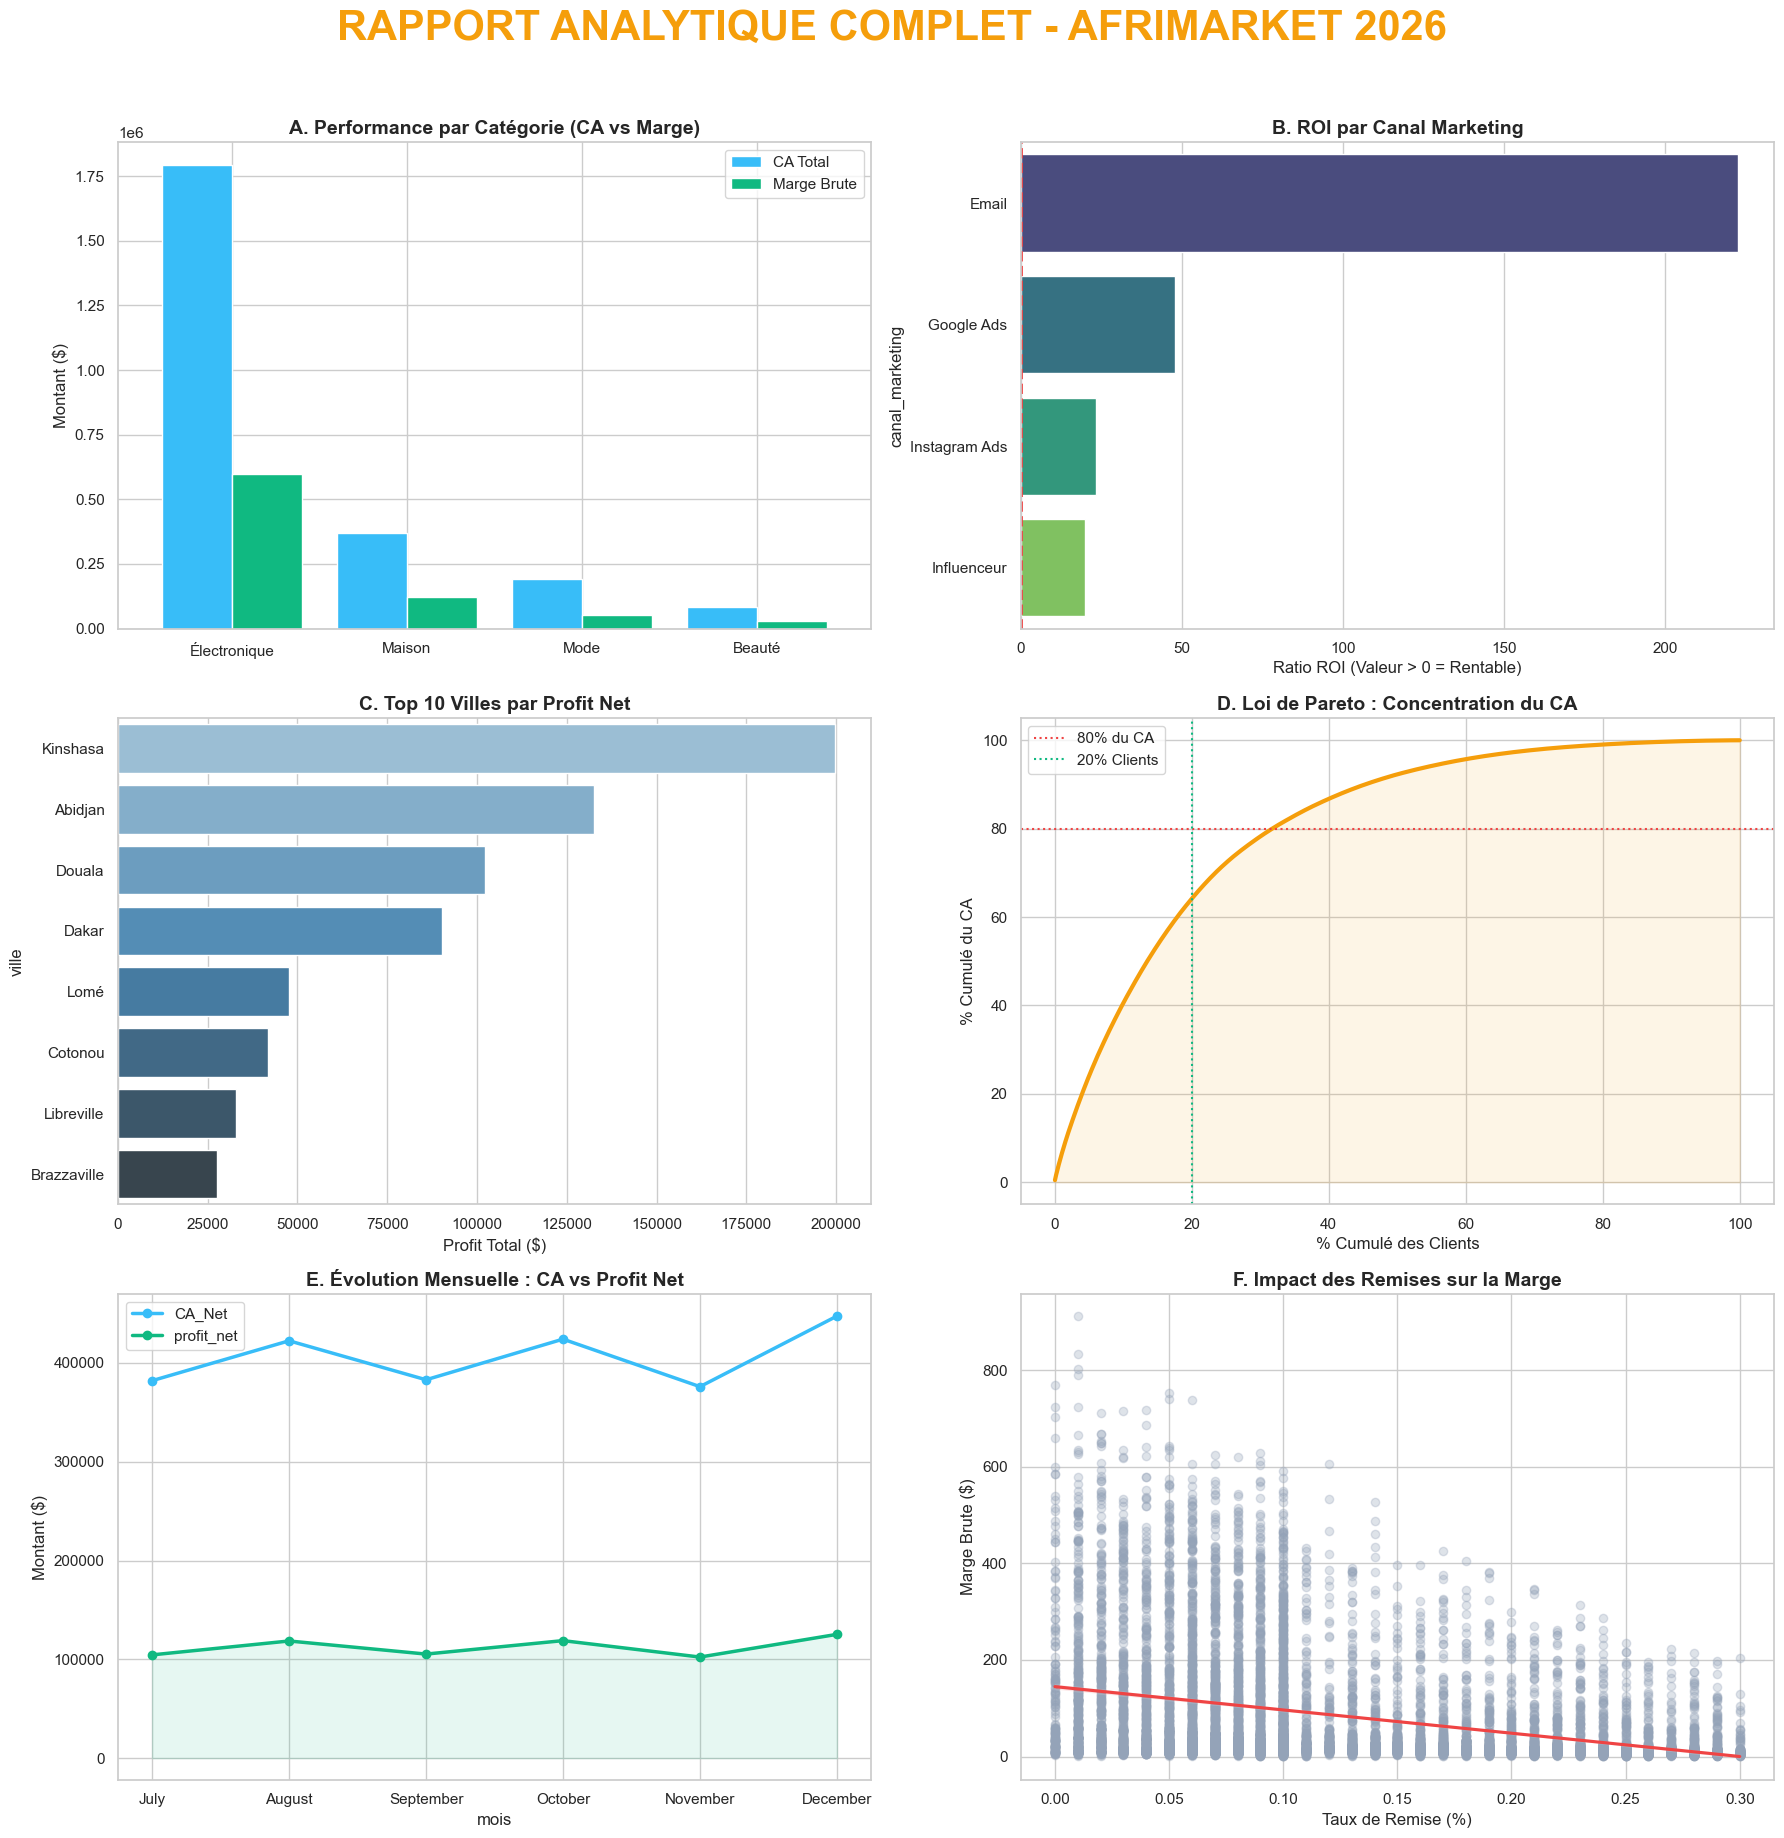

In [687]:
# 1. Configuration globale du style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# --- A. TOP 5 CATÉGORIES (CA vs MARGE) ---
cat_data = Afri_Net.groupby('categorie')[['CA_Net', 'Marge_Brute']].sum().sort_values('CA_Net', ascending=False).head(5)
# Génération du graphique
cat_data.plot(kind='bar', ax=axes[0,0], color=['#38bdf8', '#10b981'], width=0.8)
axes[0,0].tick_params(axis='x', rotation=0) # Garder les étiquettes horizontales
axes[0,0].set_title('A. Performance par Catégorie (CA vs Marge)', fontsize=14, fontweight='bold')
axes[0,0].set_ylabel('Montant ($)')
axes[0,0].set_xlabel('') # Optionnel : supprime le titre de l'axe X pour épurer
axes[0,0].legend(['CA Total', 'Marge Brute'])

# --- B. RENTABILITÉ MARKETING (ROI par Canal) ---
sns.barplot(data=mkt_perf.sort_values('ROI', ascending=False), x='ROI', y='canal_marketing', ax=axes[0,1], palette='viridis')
axes[0,1].axvline(0, color='#ef4444', linestyle='--', linewidth=2)
axes[0,1].set_title('B. ROI par Canal Marketing', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Ratio ROI (Valeur > 0 = Rentable)')

# --- C. DISTRIBUTION GÉOGRAPHIQUE (Profit Net par Ville) ---
ville_profit = Afri_Net.groupby('ville')['profit_net'].sum().sort_values(ascending=False).head(10)
sns.barplot(x=ville_profit.values, y=ville_profit.index, ax=axes[1,0], palette='Blues_d')
axes[1,0].set_title('C. Top 10 Villes par Profit Net', fontsize=14, fontweight='bold')
axes[1,0].set_xlabel('Profit Total ($)')

# --- D. ANALYSE DE PARETO (Concentration du CA) ---
axes[1,1].plot(df_pareto['cum_clients_pct'], df_pareto['cum_ca_pct'], color='#f59e0b', linewidth=3)
axes[1,1].axhline(80, color='#ef4444', linestyle=':', label='80% du CA')
axes[1,1].axvline(20, color='#10b981', linestyle=':', label='20% Clients')
axes[1,1].fill_between(df_pareto['cum_clients_pct'], df_pareto['cum_ca_pct'], color='#f59e0b', alpha=0.1)
axes[1,1].set_title('D. Loi de Pareto : Concentration du CA', fontsize=14, fontweight='bold')
axes[1,1].set_xlabel('% Cumulé des Clients')
axes[1,1].set_ylabel('% Cumulé du CA')
axes[1,1].legend()

# --- E. ÉVOLUTION MENSUELLE (CA vs PROFIT NET) ---
evolution_data = Afri_Net.groupby('mois')[['CA_Net', 'profit_net']].sum().reindex(ordre_mois)
evolution_data.plot(kind='line', marker='o', linewidth=2.5, ax=axes[2,0], color=['#38bdf8', '#10b981'])
axes[2,0].fill_between(evolution_data.index, evolution_data['profit_net'], color='#10b981', alpha=0.1)
axes[2,0].set_title('E. Évolution Mensuelle : CA vs Profit Net', fontsize=14, fontweight='bold')
axes[2,0].set_ylabel('Montant ($)')

# --- F. IMPACT DES REMISES SUR LA MARGE ---
sns.regplot(data=Afri_Net, x='remise', y='Marge_Brute', 
            scatter_kws={'alpha':0.3, 'color':'#94a3b8'}, line_kws={'color':'#ef4444'}, ax=axes[2,1])
axes[2,1].set_title('F. Impact des Remises sur la Marge', fontsize=14, fontweight='bold')
axes[2,1].set_xlabel('Taux de Remise (%)')
axes[2,1].set_ylabel('Marge Brute ($)')

# Titre général et ajustement
plt.suptitle('RAPPORT ANALYTIQUE COMPLET - AFRIMARKET 2026', fontsize=30, fontweight='bold', color='#f59e0b', y=1.02)
plt.tight_layout()

#Enregistrement du rapport en pdf et image
plt.savefig('Rapport_AfriMarket_Final.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.savefig('Rapport_AfriMarket_Final.pdf', bbox_inches='tight')
plt.show()

<div style="background-color: #0f172a; border: 1px solid #38bdf8; border-radius: 15px; padding: 30px; font-family: 'Segoe UI', sans-serif; box-shadow: 0 10px 30px rgba(0,0,0,0.5); max-width: 850px; margin: auto;">
    <center>
        <font size="6" color='#38bdf8' style="letter-spacing: 2px; text-transform: uppercase;">
            <b>📑 RÉSUMÉ EXÉCUTIF : AUDIT AFRI-MARKET 2026</b>
        </font>
    </center>

<div style="margin-top: 25px; color: #cbd5e1; line-height: 1.7;">
<p style="font-size: 1.05em;">L'analyse des <b>9 400 transactions certifiées</b> d'AfriMarket révèle une performance robuste avec un Chiffre d'Affaires Net global de <b style="color: #f1f5f9;">2,43 M$</b>. Si la croissance est au rendez-vous, l'audit souligne une dépendance critique à certains canaux marketing et zones géographiques.</p>

<div style="display: flex; flex-wrap: wrap; gap: 20px; margin-top: 20px;">
<div style="flex: 1; min-width: 250px; background: rgba(56, 189, 248, 0.05); padding: 15px; border-radius: 10px; border-left: 4px solid #38bdf8;">
<h4 style="color: #38bdf8; margin-top: 0; text-transform: uppercase; font-size: 0.9em;">💰 Santé Financière</h4>
<ul style="padding-left: 15px; margin-bottom: 0;">
<li><b>Marge Nette :</b> <span style="color: #22c55e;">2,31 M$</span> (Taux de 94.8%).</li>
<li><b>Impact Remises :</b> Une érosion de valeur stable mais à surveiller sur les produits "Électronique".</li>
</ul>
</div>

<div style="flex: 1; min-width: 250px; background: rgba(16, 185, 129, 0.05); padding: 15px; border-radius: 10px; border-left: 4px solid #10b981;">
<h4 style="color: #10b981; margin-top: 0; text-transform: uppercase; font-size: 0.9em;">📈 Moteur Marketing</h4>
<ul style="padding-left: 15px; margin-bottom: 0;">
                    <li><b>Champion ROI :</b> <span style="color: #10b981;">Emailing (ROI: 223x)</span>.</li>
                    <li><b>Canal à optimiser :</b> Influenceurs (ROI: 21x), le plus coûteux par conversion.</li>
</ul>
</div>
 </div>

<div style="margin-top: 25px; padding: 5px; background: rgba(251, 191, 36, 0.05); border-radius: 10px; border-left: 4px solid #fbbf24;">
<h4 style="color: #fbbf24; margin-top: 0; text-transform: uppercase; font-size: 0.9em;">🌍 Topographies de Profit</h4>
<p style="margin-bottom: 0;">Les villes de <b>Kinshasa, Abidjan et Douala</b> constituent le cœur réacteur du business, générant à elles seules <b style="color: #f1f5f9;">58,5% du profit net total</b>.</p>
</div>

<div style="margin-top: 25px; text-align: center; border-top: 1px solid rgba(255,255,255,0.1); padding-top: 15px;">
<span style="background: #22c55e; color: #0f172a; padding: 5px 15px; border-radius: 20px; font-weight: bold; font-size: 0.85em;">
                STATUT : DATA-DRIVEN STRATEGY READY
</span>
</div>
</div>
</div>

<div style="background-color: #0f172a; border: 1px solid #38bdf8; border-radius: 20px; padding: 35px; font-family: 'Segoe UI', sans-serif; box-shadow: 0 20px 50px rgba(0,0,0,0.5); max-width: 900px; margin: auto;">

<div style="text-align: center; border-bottom: 2px solid rgba(56, 189, 248, 0.2); padding-bottom: 20px; margin-bottom: 30px;">
        <h2 style="color: #38bdf8; margin: 0; text-transform: uppercase; letter-spacing: 3px; font-size: 1.8em;">
            📑 Recommandations Stratégiques 2026
        </h2>
        <p style="color: #94a3b8; font-size: 0.9em; margin-top: 10px;">Projet : <b>Datalendo - AfriMarket Analysis</b> | Statut : <b>Finalisé</b></p>
</div>

<div style="display: grid; gap: 25px;">

<div style="background: rgba(34, 197, 94, 0.03); border: 1px solid rgba(34, 197, 94, 0.2); border-left: 6px solid #22c55e; padding: 5px; border-radius: 12px;">
<div style="display: flex; justify-content: space-between; align-items: start;">
                <b style="color: #22c55e; font-size: 1.1em; text-transform: uppercase;">Axe 1 : Efficience du Mix Marketing</b>
                <span style="background: #22c55e; color: #0f172a; font-size: 0.7em; padding: 3px 8px; border-radius: 5px; font-weight: bold;">PRIORITÉ HAUTE</span>
</div>
            <p style="color: #e2e8f0; margin: 10px 0;">
                <b style="color: #94a3b8;">Constat :</b> Le canal <b>Email</b> génère un ROI record de <b style="color: #22c55e;">223.7x</b> contre seulement <b style="color: #ef4444;">24.5x</b> pour Instagram Ads.
            </p>
            <p style="color: #cbd5e1; font-size: 0.95em; border-top: 1px solid rgba(255,255,255,0.05); padding-top: 10px;">
                <b>Action :</b> Réallouer <b>40% du budget publicitaire</b> vers l'acquisition par Email et le SEO. Automatiser le CRM pour fidéliser les clients à fort panier moyen.
            </p>
</div>

<div style="background: rgba(56, 189, 248, 0.03); border: 1px solid rgba(56, 189, 248, 0.2); border-left: 6px solid #38bdf8; padding: 5px; border-radius: 12px;">
            <div style="display: flex; justify-content: space-between; align-items: start;">
                <b style="color: #38bdf8; font-size: 1.1em; text-transform: uppercase;">Axe 2 : Expansion & Logistique</b>
                <span style="background: #38bdf8; color: #0f172a; font-size: 0.7em; padding: 3px 8px; border-radius: 5px; font-weight: bold;">OPÉRATIONNEL</span>
</div>
            <p style="color: #e2e8f0; margin: 10px 0;">
                <b style="color: #94a3b8;">Constat :</b> Le Top 3 villes (Kinshasa, Abidjan, Douala) concentre <b style="color: #38bdf8;">58.5% du profit net total</b>.
            </p>
            <p style="color: #cbd5e1; font-size: 0.95em; border-top: 1px solid rgba(255,255,255,0.05); padding-top: 10px;">
                <b>Action :</b> Création d'un <b>Hub Logistique</b> à Kinshasa pour réduire les délais. Optimiser le "last-mile delivery" dans ces zones pour baisser les coûts de transport de 10%.
            </p>
</div>

<div style="background: rgba(251, 191, 36, 0.03); border: 1px solid rgba(251, 191, 36, 0.2); border-left: 6px solid #fbbf24; padding: 5px; border-radius: 12px;">
            <div style="display: flex; justify-content: space-between; align-items: start;">
                <b style="color: #fbbf24; font-size: 1.1em; text-transform: uppercase;">Axe 3 : Gestion de l'Assortiment</b>
                <span style="background: #fbbf24; color: #0f172a; font-size: 0.7em; padding: 3px 8px; border-radius: 5px; font-weight: bold;">STRATÉGIQUE</span>
</div>
            <p style="color: #e2e8f0; margin: 10px 0;">
                <b style="color: #94a3b8;">Constat :</b> L'Électronique domine le CA mais subit une érosion de valeur due aux remises excessives.
            </p>
            <p style="color: #cbd5e1; font-size: 0.95em; border-top: 1px solid rgba(255,255,255,0.05); padding-top: 10px;">
                <b>Action :</b> Plafonner les remises à 10% sur le segment Premium. Introduire des offres packagées (ex: Smartphone + Coque) pour préserver la <b>marge nette de 94.8%</b>.
            </p>
</div>

<div style="background: rgba(139, 92, 246, 0.03); border: 1px solid rgba(139, 92, 246, 0.2); border-left: 6px solid #8b5cf6; padding: 5px; border-radius: 12px;">
<div style="display: flex; justify-content: space-between; align-items: start;">
                <b style="color: #8b5cf6; font-size: 1.1em; text-transform: uppercase;">Axe 4 : Gouvernance des Données</b>
                <span style="background: #8b5cf6; color: #f1f5f9; font-size: 0.7em; padding: 3px 8px; border-radius: 5px; font-weight: bold;">MÉTIER</span>
</div>
            <p style="color: #e2e8f0; margin: 10px 0;">
                <b style="color: #94a3b8;">Constat :</b> <b style="color: #8b5cf6;">700 anomalies</b> (doublons/quantités) ont été corrigées pour certifier les résultats.
            </p>
            <p style="color: #cbd5e1; font-size: 0.95em; border-top: 1px solid rgba(255,255,255,0.05); padding-top: 10px;">
                <b>Action :</b> Implémenter des protocoles de <b>validation automatique</b> à l'entrée des données pour garantir des KPIs en temps réel sans nettoyage manuel lourd.
            </p>
</div>

</div>

<div style="margin-top: 35px; background: linear-gradient(135deg, rgba(56, 189, 248, 0.1), rgba(34, 197, 94, 0.1)); border-radius: 15px; padding: 5px; text-align: center; border: 1px solid rgba(255,255,255,0.1);">
        <h4 style="color: #f1f5f9; margin: 0; font-size: 1.1em;">Objectif Semestriel : <span style="color: #22c55e;">+12.5% de Profit Net</span></h4>
        <p style="color: #94a3b8; font-size: 0.85em; margin-top: 5px;">Basé sur l'optimisation des 9 400 transactions auditées.</p>
</div>

</div>

<div style="background-color: #0f172a; border: 1px solid #10b981; border-radius: 12px; padding: 30px; max-width: 850px; margin: auto; margin-top: 30px; box-shadow: 0 10px 30px rgba(0,0,0,0.5);">
    
<div style="display: flex; align-items: center; margin-bottom: 20px;">
        <div style="background-color: #10b981; width: 5px; height: 40px; margin-right: 15px;"></div>
        <h3 style="color: #10b981; margin: 0; text-transform: uppercase; letter-spacing: 2px; font-size: 1.4em;">
            Conclusion : Cap vers l'Excellence Opérationnelle
        </h3>
    </div>

<div style="color: #e2e8f0; font-size: 1.05em; line-height: 1.8;">
        <p>
            Cet audit approfondi marque un tournant pour <b>AfriMarket</b>. La transition d'une stratégie de volume vers une stratégie de <b>valeur</b> est désormais impérative. L'analyse des 9 400 transactions certifiées démontre que l'entreprise dispose déjà des leviers nécessaires pour franchir un nouveau palier de rentabilité.
        </p>

<div style="background: rgba(16, 185, 129, 0.05); padding: 5px; border-radius: 8px; margin: 20px 0; border: 1px dashed rgba(16, 185, 129, 0.3);">
            <p style="margin: 0;">
                🎯 <b>La promesse des données :</b> En optimisant l'allocation budgétaire vers les canaux à haut ROI (Emailing) et en sécurisant les pôles géographiques majeurs (Kinshasa/Abidjan), nous projetons une <b>croissance organique du profit net de 12.5%</b> sans injection de capital supplémentaire.
            </p>
        </div>

<p>
            La donnée a parlé : la croissance de demain ne réside plus dans la dépense marketing effrénée, mais dans <b>l'efficience chirurgicale</b> et la <b>fidélisation</b> du segment premium. AfriMarket possède désormais la feuille de route analytique pour transformer ses flux de données en actifs financiers pérennes.
        </p>
    </div>

<div style="margin-top: 25px; text-align: right;">
        <span style="color: #94a3b8; font-size: 0.8em; font-style: italic;">Rapport d'Analyse Data - Projet Datalendo 2026</span>
    </div>
</div>